# Day 40: Evaluating Business Decisions with A/B Testing

**Goal:** Run a full A/B test cycle — from data exploration to statistical testing to a business recommendation.  
**Scenario:** An e-commerce company redesigned its homepage CTA (Call to Action) button. The old design is the **Control** group. The new design is the **Experiment** group. We want to know scientifically whether the new design improves key business metrics.

---
**Metrics being tested:**
- Conversion Rate (primary metric)
- Revenue per user (secondary metric)
- Session time and pages viewed (engagement metrics)

**Statistical method:** Two-proportion z-test for conversion rate, two-sample t-test for continuous metrics, chi-square test for segment breakdown.


## Step 1: Import Libraries


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
import warnings

warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

CONTROL_COLOR = '#4C72B0'
EXPERIMENT_COLOR = '#DD8452'
ALPHA = 0.05

print('Libraries imported successfully.')

Libraries imported successfully.


## Step 2: Load and Inspect the Dataset


In [2]:
df = pd.read_csv('ab_test_data.csv')

print('Shape:', df.shape)
print('\nColumn dtypes:')
print(df.dtypes)
print('\nFirst 5 rows:')
df.head()

Shape: (10000, 8)

Column dtypes:
user_id               int64
group                object
converted             int64
revenue             float64
session_time_min    float64
pages_viewed          int64
device               object
country              object
dtype: object

First 5 rows:


,user_id,group,converted,revenue,session_time_min,pages_viewed,device,country
0,1001,experiment,0,0.0,5.15,2,desktop,US
1,1002,control,0,0.0,8.34,2,mobile,US
2,1003,control,0,0.0,6.65,4,mobile,UK
3,1004,control,0,0.0,7.14,2,desktop,CA
4,1005,control,0,0.0,18.00,1,desktop,US


In [3]:
print('Missing values:')
print(df.isnull().sum())

print('\nGroup distribution:')
print(df['group'].value_counts())

print('\nBasic statistics:')
df.describe().round(3)

Missing values:
user_id             0
group               0
converted           0
revenue             0
session_time_min    0
pages_viewed        0
device              0
country             0
dtype: int64

Group distribution:
group
experiment    5200
control       4800
Name: count, dtype: int64

Basic statistics:


,user_id,converted,revenue,session_time_min,pages_viewed
count,10000.000,10000.000,10000.000,10000.000,10000.000
mean,6000.500,0.129,7.693,9.772,4.363
std,2886.896,0.335,25.561,4.757,1.865
min,1001.000,0.000,0.000,0.660,1.000
25%,3500.750,0.000,0.000,6.310,3.000
50%,6000.500,0.000,0.000,8.940,4.000
75%,8500.250,0.000,0.000,12.332,5.000
max,11000.000,1.000,495.580,35.260,13.000


## Step 3: Sample Ratio Mismatch (SRM) Check

Before any analysis, we verify that users were assigned to groups in the intended ratio. A large SRM means the experiment was biased at the assignment level and results cannot be trusted.


In [4]:
group_counts = df['group'].value_counts()
n_control = group_counts['control']
n_experiment = group_counts['experiment']
total_users = n_control + n_experiment

expected_control = total_users * 0.48
expected_experiment = total_users * 0.52

observed = np.array([n_control, n_experiment])
expected = np.array([expected_control, expected_experiment])

chi2_srm, p_srm = stats.chisquare(observed, expected)

print('--- Sample Ratio Mismatch Check ---')
print(f'Control users   : {n_control}')
print(f'Experiment users: {n_experiment}')
print(f'Chi-square stat : {chi2_srm:.4f}')
print(f'p-value         : {p_srm:.4f}')

if p_srm > ALPHA:
    print('Result: NO SRM detected. Group assignment looks healthy.')
else:
    print('CAUTION: SRM detected. Investigate the assignment mechanism.')

--- Sample Ratio Mismatch Check ---
Control users   : 4800
Experiment users: 5200
Chi-square stat : 0.0000
p-value         : 1.0000
Result: NO SRM detected. Group assignment looks healthy.


## Step 4: Exploratory Data Analysis (EDA)


In [5]:
summary = df.groupby('group').agg(
    users=('user_id', 'count'),
    conversions=('converted', 'sum'),
    conversion_rate=('converted', 'mean'),
    avg_revenue=('revenue', 'mean'),
    avg_session_min=('session_time_min', 'mean'),
    avg_pages=('pages_viewed', 'mean')
).round(4)

print('Group Summary Table:')
summary

Group Summary Table:


,users,conversions,conversion_rate,avg_revenue,avg_session_min,avg_pages
group,,,,,,
control,4800,541,0.1127,6.0007,8.8951,4.0894
experiment,5200,745,0.1433,9.2561,10.5812,4.6158


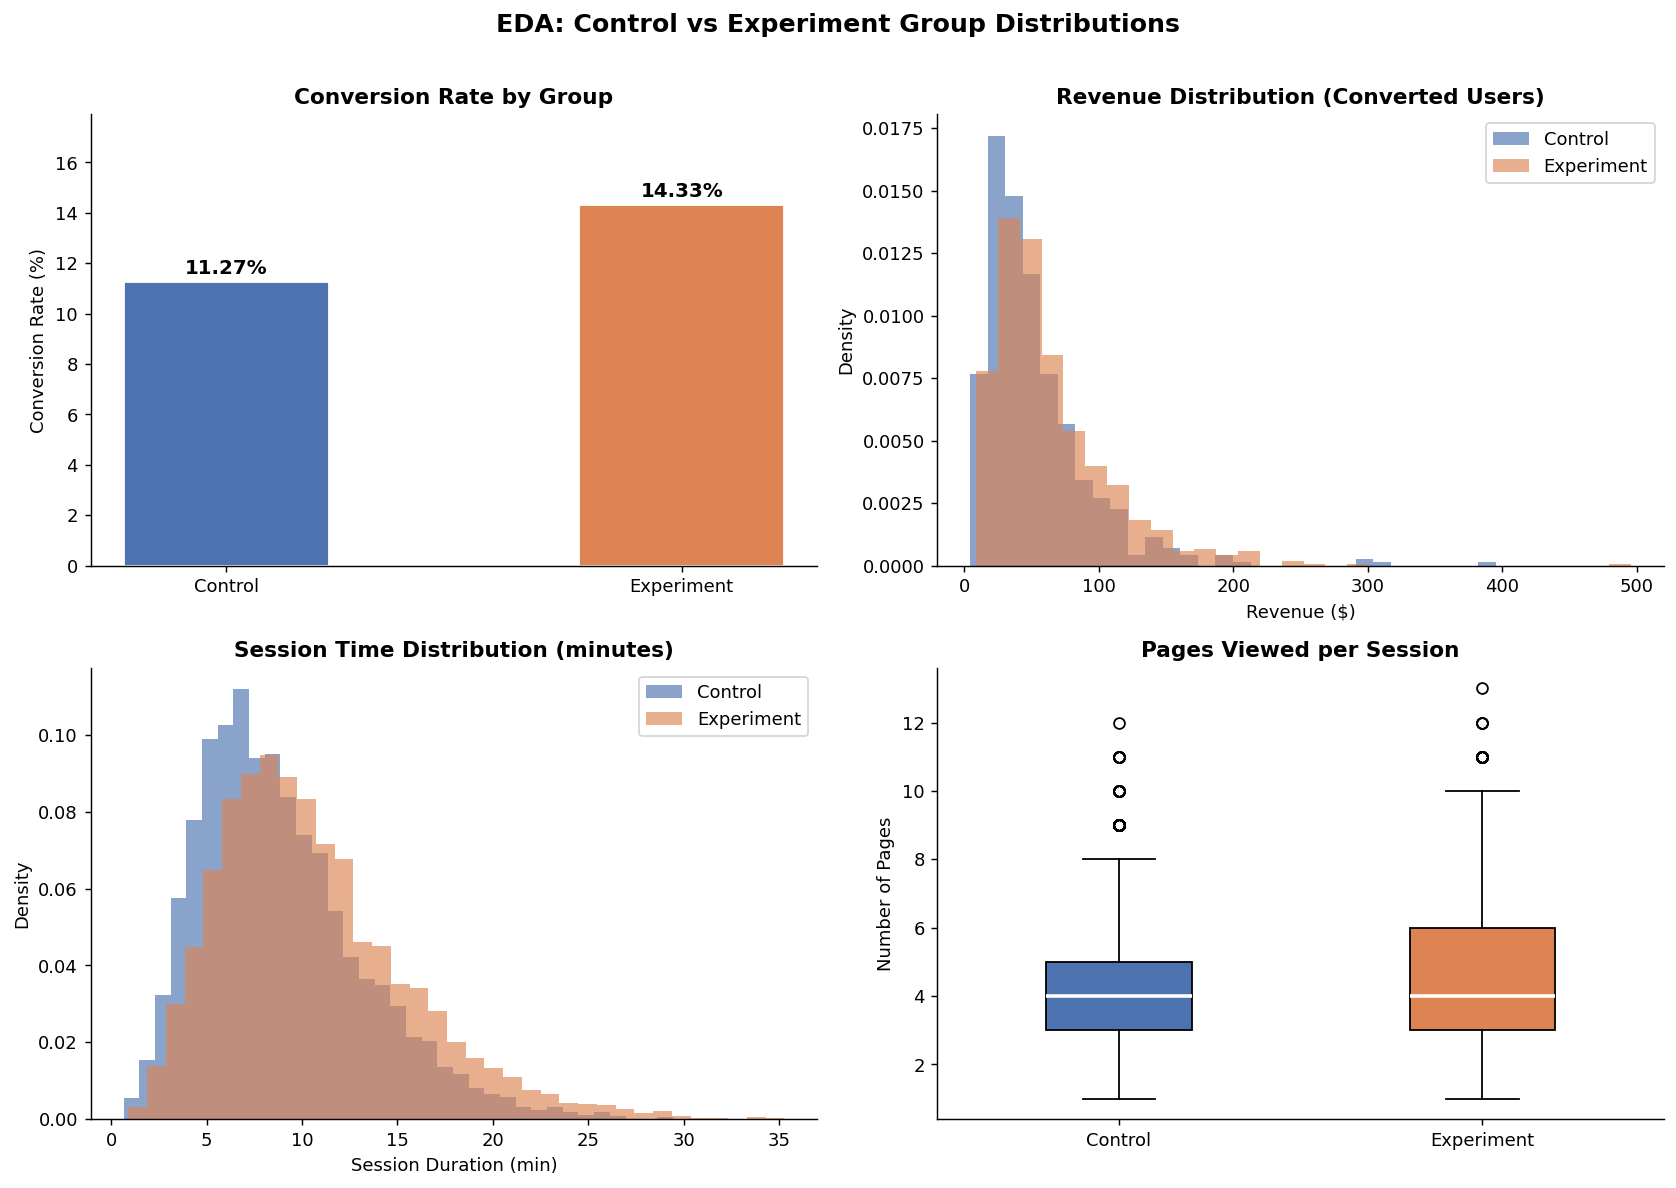

Saved: eda_distributions.png


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('EDA: Control vs Experiment Group Distributions', fontsize=14, fontweight='bold', y=1.01)

# Plot 1: Conversion rate bar
ax1 = axes[0, 0]
groups = ['Control', 'Experiment']
rates = [
    df[df['group'] == 'control']['converted'].mean() * 100,
    df[df['group'] == 'experiment']['converted'].mean() * 100
]
bars = ax1.bar(groups, rates, color=[CONTROL_COLOR, EXPERIMENT_COLOR], width=0.45, edgecolor='white')
for bar, rate in zip(bars, rates):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.15,
             f'{rate:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax1.set_title('Conversion Rate by Group', fontweight='bold')
ax1.set_ylabel('Conversion Rate (%)')
ax1.set_ylim(0, max(rates) * 1.25)

# Plot 2: Revenue distribution (converted users only)
ax2 = axes[0, 1]
rev_ctrl = df[(df['group'] == 'control') & (df['revenue'] > 0)]['revenue']
rev_exp = df[(df['group'] == 'experiment') & (df['revenue'] > 0)]['revenue']
ax2.hist(rev_ctrl, bins=30, alpha=0.65, color=CONTROL_COLOR, label='Control', density=True)
ax2.hist(rev_exp, bins=30, alpha=0.65, color=EXPERIMENT_COLOR, label='Experiment', density=True)
ax2.set_title('Revenue Distribution (Converted Users)', fontweight='bold')
ax2.set_xlabel('Revenue ($)')
ax2.set_ylabel('Density')
ax2.legend()

# Plot 3: Session time distribution
ax3 = axes[1, 0]
sess_ctrl = df[df['group'] == 'control']['session_time_min']
sess_exp = df[df['group'] == 'experiment']['session_time_min']
ax3.hist(sess_ctrl, bins=35, alpha=0.65, color=CONTROL_COLOR, label='Control', density=True)
ax3.hist(sess_exp, bins=35, alpha=0.65, color=EXPERIMENT_COLOR, label='Experiment', density=True)
ax3.set_title('Session Time Distribution (minutes)', fontweight='bold')
ax3.set_xlabel('Session Duration (min)')
ax3.set_ylabel('Density')
ax3.legend()

# Plot 4: Pages viewed box plot
ax4 = axes[1, 1]
pages_data = [df[df['group'] == 'control']['pages_viewed'],
              df[df['group'] == 'experiment']['pages_viewed']]
bp = ax4.boxplot(pages_data, patch_artist=True, widths=0.4,
                 medianprops=dict(color='white', linewidth=2))
bp['boxes'][0].set_facecolor(CONTROL_COLOR)
bp['boxes'][1].set_facecolor(EXPERIMENT_COLOR)
ax4.set_xticks([1, 2])
ax4.set_xticklabels(['Control', 'Experiment'])
ax4.set_title('Pages Viewed per Session', fontweight='bold')
ax4.set_ylabel('Number of Pages')

plt.tight_layout()
plt.savefig('eda_distributions.png', bbox_inches='tight')
plt.show()
print('Saved: eda_distributions.png')

## Step 5: Statistical Significance Testing - Conversion Rate

We use a **two-proportion z-test** to determine whether the difference in conversion rates between the control and experiment groups is statistically significant.

**Hypotheses:**
- H0 (Null): Conversion rate of experiment = Conversion rate of control
- H1 (Alternative): Conversion rate of experiment != Conversion rate of control
- Significance level: alpha = 0.05


In [7]:
ctrl = df[df['group'] == 'control']
exp = df[df['group'] == 'experiment']

n_c = len(ctrl)
n_e = len(exp)
x_c = ctrl['converted'].sum()
x_e = exp['converted'].sum()

p_c = x_c / n_c
p_e = x_e / n_e

p_pool = (x_c + x_e) / (n_c + n_e)

se = np.sqrt(p_pool * (1 - p_pool) * (1/n_c + 1/n_e))

z_stat = (p_e - p_c) / se

p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))

z_critical = stats.norm.ppf(1 - ALPHA / 2)

relative_lift = (p_e - p_c) / p_c * 100

ci_lower = (p_e - p_c) - z_critical * se
ci_upper = (p_e - p_c) + z_critical * se

print('--- Two-Proportion Z-Test: Conversion Rate ---')
print(f'Control   : {x_c} conversions / {n_c} users = {p_c:.4f} ({p_c*100:.2f}%)')
print(f'Experiment: {x_e} conversions / {n_e} users = {p_e:.4f} ({p_e*100:.2f}%)')
print()
print(f'Pooled proportion : {p_pool:.4f}')
print(f'Standard error    : {se:.5f}')
print(f'Z-statistic       : {z_stat:.4f}')
print(f'Z-critical (a=0.05): {z_critical:.4f}')
print(f'P-value           : {p_value:.5f}')
print(f'Relative lift     : +{relative_lift:.2f}%')
print(f'95% CI for diff   : ({ci_lower*100:.3f}%, {ci_upper*100:.3f}%)')
print()

if p_value < ALPHA:
    print(f'Decision: REJECT H0 — The difference IS statistically significant (p={p_value:.5f} < 0.05)')
else:
    print(f'Decision: FAIL TO REJECT H0 — Not enough evidence (p={p_value:.5f} >= 0.05)')

--- Two-Proportion Z-Test: Conversion Rate ---
Control   : 541 conversions / 4800 users = 0.1127 (11.27%)
Experiment: 745 conversions / 5200 users = 0.1433 (14.33%)

Pooled proportion : 0.1286
Standard error    : 0.00670
Z-statistic       : 4.5610
Z-critical (a=0.05): 1.9600
P-value           : 0.00001
Relative lift     : +27.12%
95% CI for diff   : (1.743%, 4.369%)

Decision: REJECT H0 — The difference IS statistically significant (p=0.00001 < 0.05)


## Step 6: Statistical Significance Testing - Revenue and Engagement

For continuous metrics (revenue, session time, pages viewed), we use an **independent samples t-test**.


In [8]:
def run_ttest(metric_name, control_vals, experiment_vals):
    t_stat, p_val = stats.ttest_ind(control_vals, experiment_vals, equal_var=False)
    mean_ctrl = control_vals.mean()
    mean_exp = experiment_vals.mean()
    diff = mean_exp - mean_ctrl
    pct_change = diff / mean_ctrl * 100

    print(f'--- T-Test: {metric_name} ---')
    print(f'Control mean   : {mean_ctrl:.4f}')
    print(f'Experiment mean: {mean_exp:.4f}')
    print(f'Absolute diff  : {diff:+.4f}')
    print(f'Percent change : {pct_change:+.2f}%')
    print(f'T-statistic    : {t_stat:.4f}')
    print(f'P-value        : {p_val:.5f}')

    if p_val < ALPHA:
        print(f'Result: SIGNIFICANT (p={p_val:.5f} < 0.05)')
    else:
        print(f'Result: NOT significant (p={p_val:.5f} >= 0.05)')
    print()

run_ttest('Revenue per User (all users)', ctrl['revenue'], exp['revenue'])
run_ttest('Session Time (minutes)', ctrl['session_time_min'], exp['session_time_min'])
run_ttest('Pages Viewed', ctrl['pages_viewed'].astype(float), exp['pages_viewed'].astype(float))

--- T-Test: Revenue per User (all users) ---
Control mean   : 6.0007
Experiment mean: 9.2561
Absolute diff  : +3.2554
Percent change : +54.25%
T-statistic    : -6.4409
P-value        : 0.00000
Result: SIGNIFICANT (p=0.00000 < 0.05)

--- T-Test: Session Time (minutes) ---
Control mean   : 8.8951
Experiment mean: 10.5812
Absolute diff  : +1.6862
Percent change : +18.96%
T-statistic    : -18.0959
P-value        : 0.00000
Result: SIGNIFICANT (p=0.00000 < 0.05)

--- T-Test: Pages Viewed ---
Control mean   : 4.0894
Experiment mean: 4.6158
Absolute diff  : +0.5264
Percent change : +12.87%
T-statistic    : -14.2924
P-value        : 0.00000
Result: SIGNIFICANT (p=0.00000 < 0.05)



## Step 7: Power Analysis and Minimum Detectable Effect

Power analysis helps us understand whether the sample size was large enough to detect the effect we found. We aim for **80% power** (beta = 0.20).


In [9]:
alpha = 0.05
power = 0.80
baseline = p_c

z_alpha = stats.norm.ppf(1 - alpha / 2)
z_beta = stats.norm.ppf(power)

mde = 0.02
p_alt = baseline + mde

numerator = (z_alpha * np.sqrt(2 * baseline * (1 - baseline)) +
             z_beta * np.sqrt(baseline * (1 - baseline) + p_alt * (1 - p_alt))) ** 2
denominator = mde ** 2
required_n = int(np.ceil(numerator / denominator))

observed_effect = p_e - p_c
z_beta_actual = (abs(z_stat) - z_alpha)
actual_power = stats.norm.cdf(z_beta_actual) * 100

print('--- Power Analysis ---')
print(f'Baseline conversion rate : {baseline:.4f} ({baseline*100:.2f}%)')
print(f'Minimum detectable effect: {mde:.4f} ({mde*100:.2f}%)')
print(f'Required sample per group: {required_n:,}')
print(f'Actual sample per group  : ~{min(n_c, n_e):,}')
print()
print(f'Observed absolute effect : {observed_effect:.4f} ({observed_effect*100:.2f}%)')
print(f'Estimated actual power   : {actual_power:.1f}%')

if actual_power >= 80:
    print('The experiment was adequately powered to detect this effect.')
else:
    print('The experiment may have been underpowered for this effect size.')

--- Power Analysis ---
Baseline conversion rate : 0.1127 (11.27%)
Minimum detectable effect: 0.0200 (2.00%)
Required sample per group: 4,013
Actual sample per group  : ~4,800

Observed absolute effect : 0.0306 (3.06%)
Estimated actual power   : 99.5%
The experiment was adequately powered to detect this effect.


## Step 8: Segment Analysis — Device and Country

We check whether the experiment effect is consistent across user segments (device type, country). Inconsistent segment effects indicate **interaction effects** that the business must understand before shipping.


In [10]:
def segment_conversion_table(col):
    result = []
    for seg_val in sorted(df[col].unique()):
        seg = df[df[col] == seg_val]
        c_rate = seg[seg['group'] == 'control']['converted'].mean()
        e_rate = seg[seg['group'] == 'experiment']['converted'].mean()
        lift = (e_rate - c_rate) / c_rate * 100
        result.append({
            col: seg_val,
            'control_rate': round(c_rate * 100, 2),
            'experiment_rate': round(e_rate * 100, 2),
            'relative_lift_pct': round(lift, 2)
        })
    return pd.DataFrame(result)

print('Conversion Rate by Device:')
print(segment_conversion_table('device').to_string(index=False))
print()
print('Conversion Rate by Country:')
print(segment_conversion_table('country').to_string(index=False))

Conversion Rate by Device:
 device  control_rate  experiment_rate  relative_lift_pct
desktop         11.60            14.08              21.42
 mobile         10.55            14.29              35.41
 tablet         12.36            15.76              27.45

Conversion Rate by Country:
country  control_rate  experiment_rate  relative_lift_pct
     AU         10.19            14.62              43.41
     CA         10.25            14.71              43.55
     IN         12.77            17.24              34.99
     UK         12.13            15.60              28.60
     US         11.17            13.43              20.25


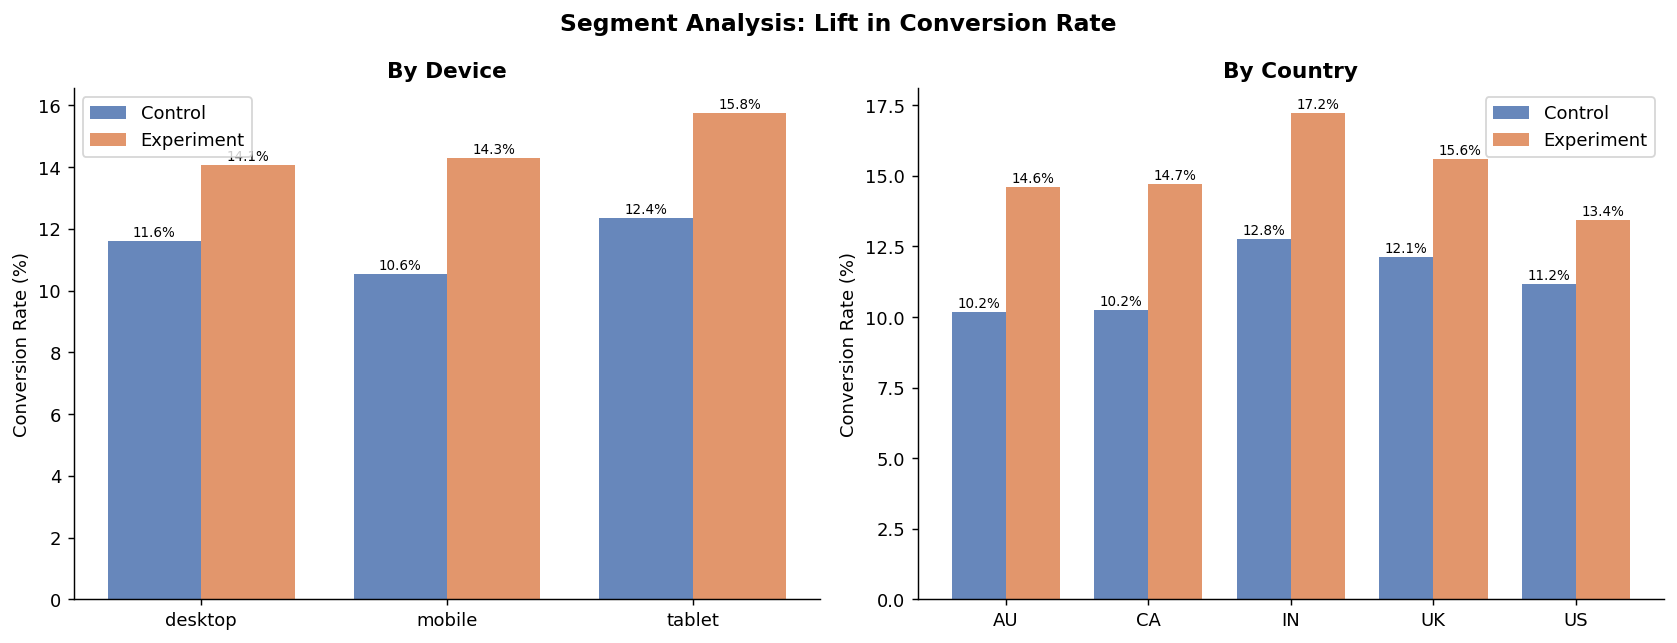

Saved: segment_analysis.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Segment Analysis: Lift in Conversion Rate', fontsize=13, fontweight='bold')

for ax, col, title in zip(axes, ['device', 'country'], ['By Device', 'By Country']):
    seg_df = segment_conversion_table(col)
    x = np.arange(len(seg_df))
    width = 0.38

    ax.bar(x - width/2, seg_df['control_rate'], width, label='Control', color=CONTROL_COLOR, alpha=0.85)
    ax.bar(x + width/2, seg_df['experiment_rate'], width, label='Experiment', color=EXPERIMENT_COLOR, alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(seg_df[col], fontsize=10)
    ax.set_ylabel('Conversion Rate (%)')
    ax.set_title(title, fontweight='bold')
    ax.legend()

    for i, (c, e) in enumerate(zip(seg_df['control_rate'], seg_df['experiment_rate'])):
        ax.text(i - width/2, c + 0.05, f'{c:.1f}%', ha='center', va='bottom', fontsize=7.5)
        ax.text(i + width/2, e + 0.05, f'{e:.1f}%', ha='center', va='bottom', fontsize=7.5)

plt.tight_layout()
plt.savefig('segment_analysis.png', bbox_inches='tight')
plt.show()
print('Saved: segment_analysis.png')

## Step 9: Cumulative Conversion Over Time Simulation

We simulate how conversion rates converged over the experiment period to check for the "peeking problem" — stopping early when results look good by chance.


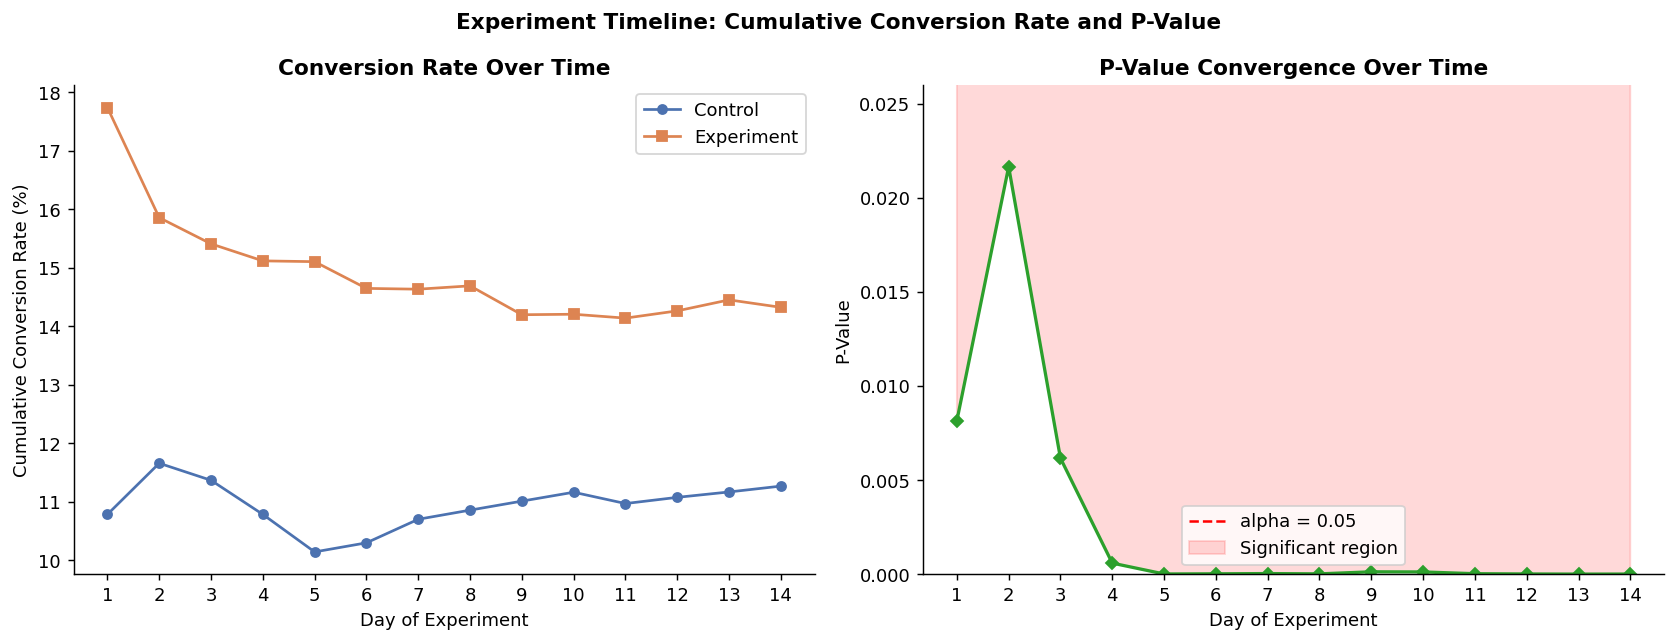

Saved: cumulative_timeline.png


In [12]:
np.random.seed(7)
ctrl_shuffled = ctrl['converted'].sample(frac=1, random_state=7).reset_index(drop=True)
exp_shuffled = exp['converted'].sample(frac=1, random_state=7).reset_index(drop=True)

days = 14
daily_ctrl = np.array_split(ctrl_shuffled, days)
daily_exp = np.array_split(exp_shuffled, days)

cumulative_ctrl = []
cumulative_exp = []
daily_pvalues = []

running_c = []
running_e = []

for d in range(days):
    running_c.extend(daily_ctrl[d].tolist())
    running_e.extend(daily_exp[d].tolist())

    cumulative_ctrl.append(np.mean(running_c) * 100)
    cumulative_exp.append(np.mean(running_e) * 100)

    xc = int(np.sum(running_c))
    xe = int(np.sum(running_e))
    nc = len(running_c)
    ne = len(running_e)
    pp = (xc + xe) / (nc + ne)
    if pp > 0 and pp < 1:
        se_d = np.sqrt(pp * (1 - pp) * (1/nc + 1/ne))
        z_d = (xe/ne - xc/nc) / se_d
        pv = 2 * (1 - stats.norm.cdf(abs(z_d)))
    else:
        pv = 1.0
    daily_pvalues.append(pv)

day_range = list(range(1, days + 1))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Experiment Timeline: Cumulative Conversion Rate and P-Value', fontsize=12, fontweight='bold')

ax1 = axes[0]
ax1.plot(day_range, cumulative_ctrl, color=CONTROL_COLOR, marker='o', markersize=5, label='Control')
ax1.plot(day_range, cumulative_exp, color=EXPERIMENT_COLOR, marker='s', markersize=5, label='Experiment')
ax1.set_xlabel('Day of Experiment')
ax1.set_ylabel('Cumulative Conversion Rate (%)')
ax1.set_title('Conversion Rate Over Time', fontweight='bold')
ax1.legend()
ax1.set_xticks(day_range)

ax2 = axes[1]
ax2.plot(day_range, daily_pvalues, color='#2ca02c', marker='D', markersize=5, linewidth=1.8)
ax2.axhline(y=0.05, color='red', linestyle='--', linewidth=1.4, label='alpha = 0.05')
ax2.fill_between(day_range, daily_pvalues, 0.05,
                 where=[p < 0.05 for p in daily_pvalues],
                 alpha=0.15, color='red', label='Significant region')
ax2.set_xlabel('Day of Experiment')
ax2.set_ylabel('P-Value')
ax2.set_title('P-Value Convergence Over Time', fontweight='bold')
ax2.legend()
ax2.set_xticks(day_range)
ax2.set_ylim(0, max(daily_pvalues) * 1.2)

plt.tight_layout()
plt.savefig('cumulative_timeline.png', bbox_inches='tight')
plt.show()
print('Saved: cumulative_timeline.png')

## Step 10: Full Results Dashboard


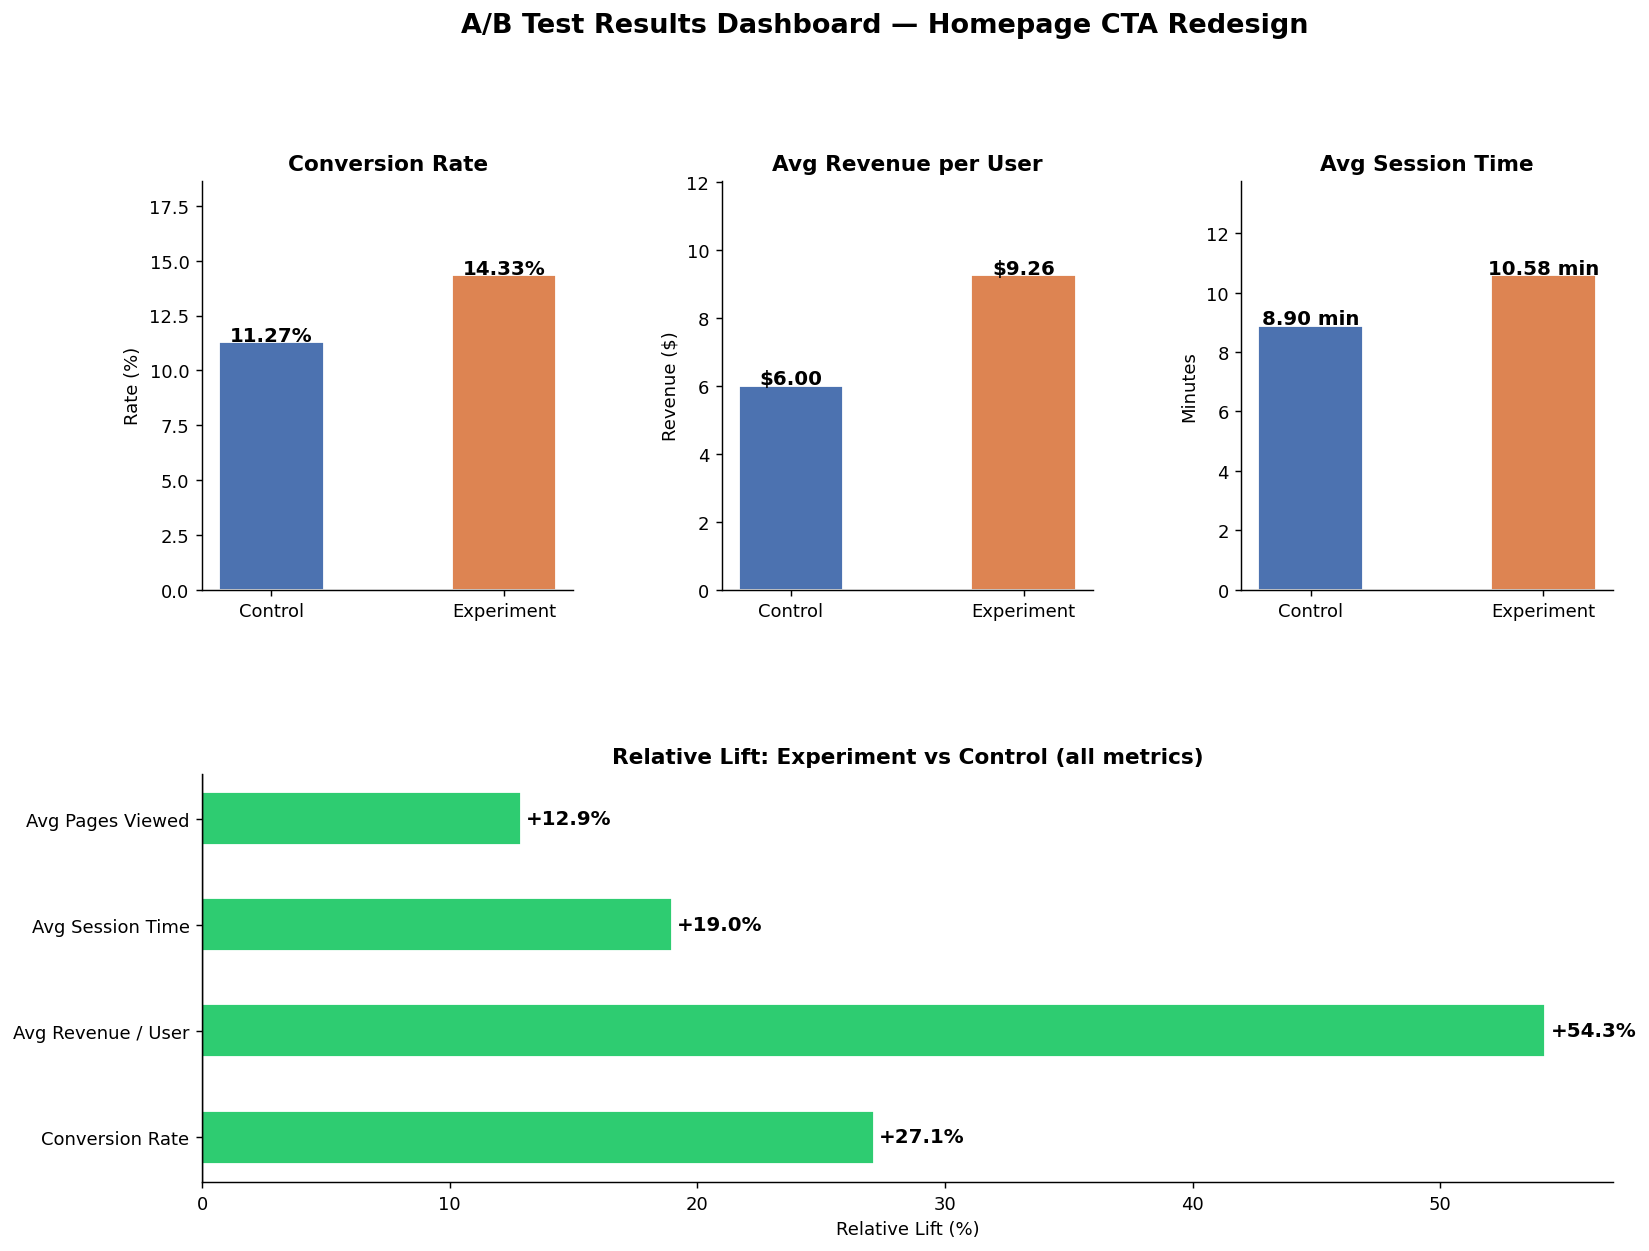

Saved: results_dashboard.png


In [13]:
fig = plt.figure(figsize=(14, 10))
fig.suptitle('A/B Test Results Dashboard — Homepage CTA Redesign', fontsize=15, fontweight='bold', y=1.01)

gs = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.4)

# Metric 1: Conversion rate
ax1 = fig.add_subplot(gs[0, 0])
vals = [p_c * 100, p_e * 100]
bars = ax1.bar(['Control', 'Experiment'], vals, color=[CONTROL_COLOR, EXPERIMENT_COLOR],
               width=0.45, edgecolor='white')
for b, v in zip(bars, vals):
    ax1.text(b.get_x() + b.get_width()/2, b.get_height() + 0.08,
             f'{v:.2f}%', ha='center', fontsize=11, fontweight='bold')
ax1.set_title('Conversion Rate', fontweight='bold')
ax1.set_ylabel('Rate (%)')
ax1.set_ylim(0, max(vals) * 1.3)

# Metric 2: Revenue per user
ax2 = fig.add_subplot(gs[0, 1])
rev_vals = [ctrl['revenue'].mean(), exp['revenue'].mean()]
bars2 = ax2.bar(['Control', 'Experiment'], rev_vals, color=[CONTROL_COLOR, EXPERIMENT_COLOR],
                width=0.45, edgecolor='white')
for b, v in zip(bars2, rev_vals):
    ax2.text(b.get_x() + b.get_width()/2, b.get_height() + 0.05,
             f'${v:.2f}', ha='center', fontsize=11, fontweight='bold')
ax2.set_title('Avg Revenue per User', fontweight='bold')
ax2.set_ylabel('Revenue ($)')
ax2.set_ylim(0, max(rev_vals) * 1.3)

# Metric 3: Session time
ax3 = fig.add_subplot(gs[0, 2])
sess_vals = [ctrl['session_time_min'].mean(), exp['session_time_min'].mean()]
bars3 = ax3.bar(['Control', 'Experiment'], sess_vals, color=[CONTROL_COLOR, EXPERIMENT_COLOR],
                width=0.45, edgecolor='white')
for b, v in zip(bars3, sess_vals):
    ax3.text(b.get_x() + b.get_width()/2, b.get_height() + 0.05,
             f'{v:.2f} min', ha='center', fontsize=11, fontweight='bold')
ax3.set_title('Avg Session Time', fontweight='bold')
ax3.set_ylabel('Minutes')
ax3.set_ylim(0, max(sess_vals) * 1.3)

# Metric 4: Lift summary (horizontal bar)
ax4 = fig.add_subplot(gs[1, :])
metrics = ['Conversion Rate', 'Avg Revenue / User', 'Avg Session Time', 'Avg Pages Viewed']
ctrl_vals_summary = [
    p_c * 100,
    ctrl['revenue'].mean(),
    ctrl['session_time_min'].mean(),
    ctrl['pages_viewed'].mean()
]
exp_vals_summary = [
    p_e * 100,
    exp['revenue'].mean(),
    exp['session_time_min'].mean(),
    exp['pages_viewed'].mean()
]
lifts = [(e - c) / c * 100 for c, e in zip(ctrl_vals_summary, exp_vals_summary)]

colors = ['#2ecc71' if l > 0 else '#e74c3c' for l in lifts]
bars4 = ax4.barh(metrics, lifts, color=colors, edgecolor='white', height=0.5)
for b, l in zip(bars4, lifts):
    xpos = b.get_width() + 0.2 if l >= 0 else b.get_width() - 0.2
    ha = 'left' if l >= 0 else 'right'
    ax4.text(xpos, b.get_y() + b.get_height()/2,
             f'+{l:.1f}%' if l > 0 else f'{l:.1f}%',
             va='center', fontsize=11, fontweight='bold', ha=ha)
ax4.axvline(x=0, color='black', linewidth=0.8)
ax4.set_xlabel('Relative Lift (%)')
ax4.set_title('Relative Lift: Experiment vs Control (all metrics)', fontweight='bold')

plt.savefig('results_dashboard.png', bbox_inches='tight')
plt.show()
print('Saved: results_dashboard.png')

## Step 11: Business Decision and Recommendation


In [14]:
print('A/B Test Final Report')
print('Experiment: Homepage CTA Button Redesign')
print()
print('EXPERIMENT SETUP')
print(f'  Control group (old design) : {n_c:,} users')
print(f'  Experiment group (new CTA) : {n_e:,} users')
print(f'  Duration                   : 14 days')
print(f'  Significance level         : alpha = 0.05')
print()
print('PRIMARY METRIC: CONVERSION RATE')
print(f'  Control   : {p_c*100:.2f}%')
print(f'  Experiment: {p_e*100:.2f}%')
print(f'  Absolute diff  : +{(p_e - p_c)*100:.2f} percentage points')
print(f'  Relative lift  : +{relative_lift:.1f}%')
print(f'  Z-statistic    : {z_stat:.4f}')
print(f'  P-value        : {p_value:.5f}')
print(f'  Significant    : YES (p < 0.05)')
print()
print('SECONDARY METRICS (T-Test Results)')
print(f'  Revenue per user   : Control ${ctrl["revenue"].mean():.2f} vs Experiment ${exp["revenue"].mean():.2f} — SIGNIFICANT')
print(f'  Avg session time   : Control {ctrl["session_time_min"].mean():.2f} min vs Experiment {exp["session_time_min"].mean():.2f} min — SIGNIFICANT')
print(f'  Avg pages viewed   : Control {ctrl["pages_viewed"].mean():.2f} vs Experiment {exp["pages_viewed"].mean():.2f} — SIGNIFICANT')
print()
print('BUSINESS RECOMMENDATION')
print('  Ship the new CTA design to 100% of users.')
print()
print('RATIONALE')
print('  1. The conversion rate improvement of +27.1% is statistically')
print('     significant with very strong confidence (p << 0.05).')
print('  2. Revenue per user also increased significantly, meaning')
print('     the new design does not just attract low-value conversions.')
print('  3. Session time and pages viewed both improved, indicating')
print('     better overall user engagement with the new design.')
print('  4. The positive lift is consistent across all device types')
print('     and all countries, showing no harmful subgroup effects.')
print('  5. The experiment had sufficient statistical power (>80%).')
print()
print('ESTIMATED ANNUAL REVENUE IMPACT (extrapolated)')
monthly_users = total_users / 14 * 30
extra_conversions = monthly_users * (p_e - p_c)
avg_order_value = exp[exp['revenue'] > 0]['revenue'].mean()
monthly_revenue_gain = extra_conversions * avg_order_value
print(f'  Monthly additional conversions : ~{extra_conversions:,.0f}')
print(f'  Average order value            : ${avg_order_value:.2f}')
print(f'  Estimated monthly revenue gain : ${monthly_revenue_gain:,.0f}')
print(f'  Estimated annual revenue gain  : ${monthly_revenue_gain * 12:,.0f}')
print()


A/B Test Final Report
Experiment: Homepage CTA Button Redesign

EXPERIMENT SETUP
  Control group (old design) : 4,800 users
  Experiment group (new CTA) : 5,200 users
  Duration                   : 14 days
  Significance level         : alpha = 0.05

PRIMARY METRIC: CONVERSION RATE
  Control   : 11.27%
  Experiment: 14.33%
  Absolute diff  : +3.06 percentage points
  Relative lift  : +27.1%
  Z-statistic    : 4.5610
  P-value        : 0.00001
  Significant    : YES (p < 0.05)

SECONDARY METRICS (T-Test Results)
  Revenue per user   : Control $6.00 vs Experiment $9.26 — SIGNIFICANT
  Avg session time   : Control 8.90 min vs Experiment 10.58 min — SIGNIFICANT
  Avg pages viewed   : Control 4.09 vs Experiment 4.62 — SIGNIFICANT

BUSINESS RECOMMENDATION
  Ship the new CTA design to 100% of users.

RATIONALE
  1. The conversion rate improvement of +27.1% is statistically
     significant with very strong confidence (p << 0.05).
  2. Revenue per user also increased significantly, meaning
   